# Part 2 Implementation with pretrained CNN

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# import sk learn libraries
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score, StratifiedGroupKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score

# Importing CNN Model
import torch
from torchvision import models, transforms
import cv2

## Load Data / PreProcessing

In [3]:
img_file      = 'x_train_img.npz'
metadata_file = 'x_train.csv'
y_file        = 'y_train.csv'

X_dev = pd.read_csv(metadata_file).replace('UNK', np.nan)
Y_dev = pd.read_csv(y_file)

groups = X_dev['patient_id'].values   # keep aside for grouped CV

def load_img_data(path):
    with np.load(path) as data:
        return data['images'], data['image_ids']

imgs, img_ids = load_img_data(img_file)
print(f'Loaded {imgs.shape[0]} images of shape {imgs.shape[1:]}')
assert np.all(img_ids == X_dev['img_id'].values), 'image / metadata id mismatch'

Loaded 1178 images of shape (256, 256, 3)


## Encode Categorical Features

In [4]:
# These are the 3 columns in X that have categorical data.
# Everything else is binary or numeric. 
categorical_cols = ['background_father', 'background_mother', 'region'] 

# Get all obvious true/false cols that aren't already true/false
for col in X_dev.select_dtypes(include=['object']):
    if X_dev[col].dropna().astype(str).str.contains('True|False').any():
        print(f"Automatically converting {col} to binary...")
        unmapped = X_dev[~X_dev[col].isin(['True','False'])][col].unique()
        print("The following values are being mapped to NaN in this column: ", unmapped)
        X_dev[col] = X_dev[col].map({'True': 1, 'False': 0, True: 1, False: 0})

X_dev['gender'] = X_dev['gender'].map({'MALE': 0, 'FEMALE': 1})

# Handle the categorical data
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoded_feats = encoder.fit_transform(X_dev[categorical_cols])
encoded_df = pd.DataFrame(
    encoded_feats, 
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_dev.index
)

# Drop original text columns and join the new numeric ones
X_dev = X_dev.drop(columns=categorical_cols).join(encoded_df)

X_tab_df = X_dev.drop(columns=['patient_id', 'img_id'])
X_tab    = X_tab_df.values.astype(float)
num_tabular_cols = X_tab.shape[1]   # captured AFTER encoding -- correct now
print('tabular feature matrix:', X_tab.shape)
print('missing per column (top 10):')
print(X_tab_df.isna().sum().sort_values(ascending=False).head(10))


Automatically converting itch to binary...
The following values are being mapped to NaN in this column:  [nan]
Automatically converting grew to binary...
The following values are being mapped to NaN in this column:  [nan]
Automatically converting hurt to binary...
The following values are being mapped to NaN in this column:  [nan]
Automatically converting changed to binary...
The following values are being mapped to NaN in this column:  [nan]
Automatically converting bleed to binary...
The following values are being mapped to NaN in this column:  [nan]
Automatically converting elevation to binary...
The following values are being mapped to NaN in this column:  [nan]
tabular feature matrix: (1178, 55)
missing per column (top 10):
grew                           323
changed                        319
hurt                             8
itch                             4
bleed                            4
elevation                        2
background_mother_POLAND         0
background_mothe

## Set Up CNN

In [5]:
def extract_mobilenet_features(images_np, batch_size=32):
    """images_np: (N, H, W, 3) uint8/float -> (N, 1280) float32"""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
    feature_extractor = model.features.eval().to(device)

    preprocess = transforms.Compose([
        transforms.Resize(256, antialias=True),
        transforms.CenterCrop(224),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std =[0.229, 0.224, 0.225]),
    ])

    images_tensor = torch.tensor(images_np, dtype=torch.float32).permute(0, 3, 1, 2) / 255.0

    out = []
    with torch.no_grad():
        for i in range(0, len(images_tensor), batch_size):
            batch = images_tensor[i:i+batch_size].to(device)
            batch = torch.stack([preprocess(img) for img in batch])
            feats = feature_extractor(batch)
            pooled = torch.nn.functional.adaptive_avg_pool2d(feats, 1).flatten(1)
            out.append(pooled.cpu().numpy())
    return np.vstack(out).astype(np.float32)

import os
cache_path = 'mobilenet_features_train.npy'
if os.path.exists(cache_path):
    img_features = np.load(cache_path)
    print(f'loaded cached features {img_features.shape}')
else:
    img_features = extract_mobilenet_features(imgs)
    np.save(cache_path, img_features)
    print(f'extracted features {img_features.shape}')

loaded cached features (1178, 1280)


In [6]:
# img_features = extract_mobilenet_features(imgs)
# np.save('mobilenet_features_train.npy', img_features)

In [7]:
img_features = np.load('mobilenet_features_train.npy')

## Unified Pipeline with XGBoost + CNN Return Value

In [8]:
y_train = Y_dev['coarse_label'].values
n_pos = int((y_train == 1).sum())
n_neg = int((y_train == 0).sum())
print(f'label=1 count: {n_pos}')
print(f'label=0 count: {n_neg}')
print(f'minority class is label={0 if n_neg < n_pos else 1} '
      f'({min(n_pos, n_neg)} / {n_pos + n_neg} = {min(n_pos, n_neg)/(n_pos+n_neg):.1%})')

# XGBoost convention: scale_pos_weight = sum(neg) / sum(pos)
scale_pos_weight = n_neg / n_pos
print(f'scale_pos_weight = {scale_pos_weight:.4f}')

label=1 count: 1089
label=0 count: 89
minority class is label=0 (89 / 1178 = 7.6%)
scale_pos_weight = 0.0817


### Hyperparameter Setup

In [9]:
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

In [10]:
x_train = np.hstack([X_tab, img_features])
print('x_train:', x_train.shape, '   tabular cols [0:%d), image cols [%d:%d)'
      % (num_tabular_cols, num_tabular_cols, x_train.shape[1]))

tabular_indices = list(range(num_tabular_cols))
image_indices   = list(range(num_tabular_cols, x_train.shape[1]))

x_train: (1178, 1335)    tabular cols [0:55), image cols [55:1335)


In [11]:
# Calculate weights for each row in your training set
num_neg = (y_train == 0).sum()
num_pos = (y_train == 1).sum()
imbalance_ratio = num_neg / num_pos

In [12]:
# Find the exact index of the 'age' column from your tabular dataframe
age_idx = X_tab_df.columns.get_loc('age')

def min_age_group_auroc(estimator, X, y_true):
    # 1. Get the model's predicted probabilities for the positive class
    y_proba = estimator.predict_proba(X)[:, 1]
    
    # 2. Extract the unscaled 'age' column from the raw validation fold 
    ages = X[:, age_idx]
    
    # 3. Create boolean masks for the 3 required age groups
    masks = {
        'young': ages < 30,
        'adult': (ages >= 30) & (ages < 60),
        'senior': ages >= 60
    }
    
    aucs = []
    
    # 4. Calculate AUROC for each group
    for group, mask in masks.items():
        y_true_group = y_true[mask]
        y_proba_group = y_proba[mask]
        
        # Safety Check: roc_auc_score crashes if a fold only has 1 class (all 0s or all 1s). 
        # This can happen in small groups during 5-fold CV.
        if len(np.unique(y_true_group)) == 2:
            aucs.append(roc_auc_score(y_true_group, y_proba_group))
            
    # 5. Return the minimum AUROC across the successful groups
    return np.min(aucs) if aucs else 0.0

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ('tab_prep', Pipeline([
            ('imputer', KNNImputer(n_neighbors=5)),
            ('scaler', StandardScaler())
        ]), tabular_indices),
        ('img', Pipeline([
            ('scaler', StandardScaler()),
            ('pca', PCA(n_components=50, random_state=101)),
        ]), image_indices),
    ],
    remainder='passthrough' 
)

full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        objective='binary:logistic',
        eval_metric='aucpr',
        tree_method='hist',
        random_state=101,
        n_jobs=1,            
    )),
])

In [14]:
xgb_model_hyperparameters = dict(
    learning_rate = [0.01, 0.05, 0.1],
    n_estimators = [100,500,1000],
    max_depth = [4,8,16,32],
)

In [15]:
sgkf = StratifiedGroupKFold(n_splits=5)

pipeline_hyperparameters = {
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__n_estimators': [100, 500, 1000],
    'classifier__max_depth': [4, 6, 8],
}

In [16]:
grid_search = GridSearchCV(
    estimator=full_pipeline,
    param_grid=pipeline_hyperparameters,
    scoring=min_age_group_auroc,
    cv=sgkf,             
    return_train_score=True,
    refit=True
)

In [17]:
grid_search.fit(x_train, y_train, groups=groups)

print('best min age-group AUROC (CV)', round(grid_search.best_score_, 4))

best min age-group AUROC (CV) 0.7976


## Predict on Held Out Test Set

In [18]:
test_metadata_file = 'x_test.csv'
test_img_file      = 'x_test_img.npz'

X_test_meta = pd.read_csv(test_metadata_file).replace('UNK', np.nan)
test_imgs, test_img_ids = load_img_data(test_img_file)
print(f'test metadata: {X_test_meta.shape}, test images: {test_imgs.shape}')

test metadata: (296, 23), test images: (296, 256, 256, 3)


In [19]:
# Replicate the training-time encoding on the test metadata.
# Using the SAME fit `encoder` so columns / category order line up.

# 1) True/False -> 0/1 (auto-detect, matches the training rule)
for col in X_test_meta.select_dtypes(include=['object']):
    if X_test_meta[col].dropna().astype(str).str.contains('True|False').any():
        X_test_meta[col] = X_test_meta[col].map({'True': 1, 'False': 0, True: 1, False: 0})

X_test_meta['gender'] = X_test_meta['gender'].map({'MALE': 0, 'FEMALE': 1})

# 2) Missing-indicators (same columns as train)
for col in ['grew', 'changed', 'itch', 'hurt', 'bleed', 'elevation']:
    X_test_meta[f'{col}_missing'] = X_test_meta[col].isna().astype(int)

# 3) One-hot encode using the SAME fit encoder (handle_unknown='ignore' covers
#    any country/region that didn't appear in train; they get all zeros).
encoded_test = encoder.transform(X_test_meta[categorical_cols])
encoded_test_df = pd.DataFrame(
    encoded_test,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_test_meta.index,
)
X_test_meta = X_test_meta.drop(columns=categorical_cols).join(encoded_test_df)

# 4) Drop identifiers, then reindex to the training column order. fill_value=0 is
#    correct for any one-hot column that didn't appear in test.
X_test_tab_df = X_test_meta.drop(columns=['patient_id', 'img_id'])
X_test_tab_df = X_test_tab_df.reindex(columns=X_tab_df.columns, fill_value=0)
X_test_tab    = X_test_tab_df.values.astype(float)

print('test tabular matrix:', X_test_tab.shape, '(should match train cols:', X_tab.shape[1], ')')
assert X_test_tab.shape[1] == X_tab.shape[1], 'tabular column count mismatch with training'

test tabular matrix: (296, 55) (should match train cols: 55 )


In [20]:
# CNN features for the test images. Cached so re-runs are cheap.
test_cache = 'mobilenet_features_test.npy'
if os.path.exists(test_cache):
    test_img_features = np.load(test_cache)
    print(f'loaded cached test features {test_img_features.shape}')
else:
    test_img_features = extract_mobilenet_features(test_imgs)
    np.save(test_cache, test_img_features)
    print(f'extracted test features {test_img_features.shape}')

loaded cached test features (296, 1280)


In [21]:
x_test_final = np.hstack([X_test_tab, test_img_features])
assert x_test_final.shape[1] == x_train.shape[1], (
    f'final feature-dim mismatch: train={x_train.shape[1]} vs test={x_test_final.shape[1]}'
)

y_proba = grid_search.predict_proba(x_test_final)[:, 1]

np.savetxt('yproba1_test.txt', y_proba)

In [22]:
def plot_xgb_hyperparam_curve(results, param_name, fixed_params):
    """
    Plots train vs validation AUROC over a given hyperparameter,
    with individual fold scores shown as dots.
    
    params:
        results: cv_results_ dataframe from GridSearchCV
        param_name: the hyperparameter to plot e.g. 'param_classifier__max_depth'
        fixed_params: dict of other params to filter on
                      e.g. {'param_classifier__n_estimators': 100, 'param_classifier__learning_rate': 0.01}
    """
    results = pd.DataFrame(grid_search.cv_results_)
    
    # Apply fixed param filters
    mask = pd.Series([True] * len(results), index=results.index)
    for col, val in fixed_params.items():
        mask &= (results[col] == val)
    filtered = results[mask]

    # Get number of folds from the split score columns
    n_folds = len([c for c in results.columns if c.startswith('split') and c.endswith('test_score')])
    
    # Plot individual fold dots
    for i in range(n_folds):
        fold_train = f'split{i}_train_score'
        fold_val = f'split{i}_test_score'
        plt.scatter(filtered[param_name], filtered[fold_train],
                    color='steelblue', alpha=0.3, s=20,
                    label='Train fold' if i == 0 else None)
        plt.scatter(filtered[param_name], filtered[fold_val],
                    color='orange', alpha=0.3, s=20,
                    label='Val fold' if i == 0 else None)

    # Group by the target param and plot mean lines
    grouped = filtered.groupby(param_name).agg(
        mean_train=('mean_train_score', 'mean'),
        mean_val=('mean_test_score', 'mean')
    ).reset_index()

    plt.plot(grouped[param_name], grouped['mean_train'],
             label='Mean Train AUROC', marker='o', color='steelblue')
    plt.plot(grouped[param_name], grouped['mean_val'],
             label='Mean Validation AUROC', marker='o', color='orange')

    plt.xlabel(param_name.replace('param_classifier__', ''))
    plt.ylabel('Min Age-Group AUROC')
    plt.title(f'Train vs Validation AUROC by {param_name.replace("param_classifier__", "")}')
    plt.legend()
    plt.show()

In [23]:
# print out the best params
for param, value in grid_search.best_params_.items():
    print(f"{param.replace('classifier__', '')}: {value}")

learning_rate: 0.05
max_depth: 4
n_estimators: 1000


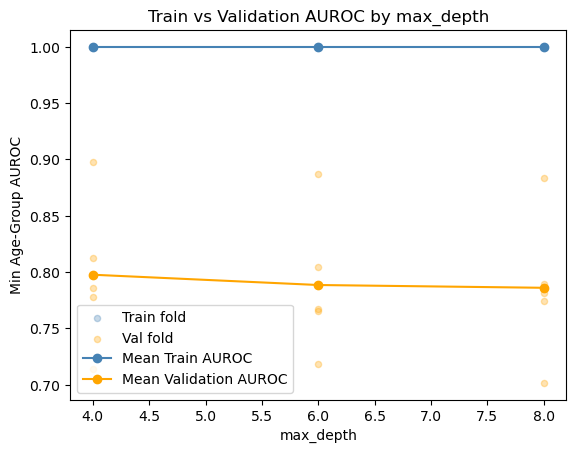

In [24]:
plot_xgb_hyperparam_curve(
    results=grid_search.cv_results_,
    param_name='param_classifier__max_depth',
    fixed_params={
        'param_classifier__n_estimators': 1000,
        'param_classifier__learning_rate': 0.05
    }
)

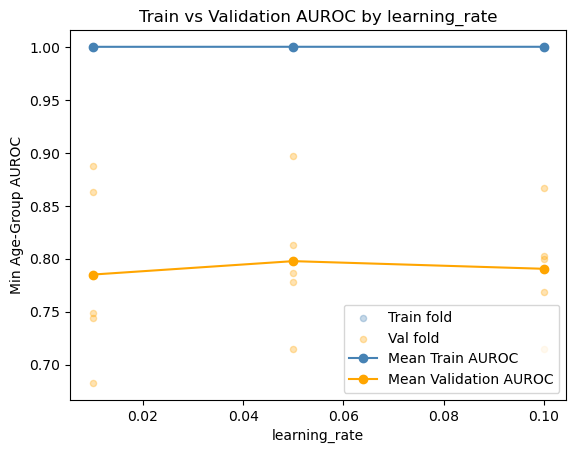

In [25]:
plot_xgb_hyperparam_curve(
    results=grid_search.cv_results_,
    param_name='param_classifier__learning_rate',
    fixed_params={
        'param_classifier__n_estimators': 1000,
        'param_classifier__max_depth': 4
    }
)

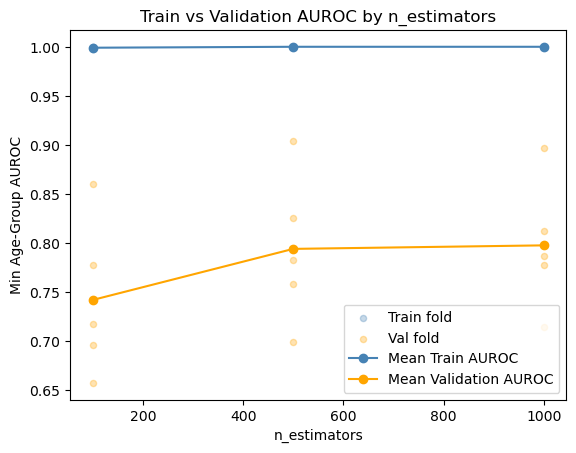

In [26]:
plot_xgb_hyperparam_curve(
    results=grid_search.cv_results_,
    param_name='param_classifier__n_estimators',
    fixed_params={
        'param_classifier__max_depth': 4,
        'param_classifier__learning_rate': 0.05
    }
)

In [28]:
from sklearn.model_selection import cross_val_predict

y_proba = cross_val_predict(
    grid_search.best_estimator_,
    x_train,
    y_train,
    cv=sgkf,
    method='predict_proba',
    groups=groups
)[:, 1]

y_true = y_train
y_pred = (y_proba >= 0.5).astype(int)
confidence = np.abs(y_proba - 0.5)

correct_mask = y_pred == y_true
incorrect_mask = ~correct_mask

correct_indices = np.where(correct_mask)[0]
top_correct = correct_indices[np.argsort(confidence[correct_indices])[::-1][:3]]

incorrect_indices = np.where(incorrect_mask)[0]
top_incorrect = incorrect_indices[np.argsort(confidence[incorrect_indices])[::-1][:3]]

print("Most confident and CORRECT:")
for idx in top_correct:
    print(f"  Index {idx} | True: {y_true[idx]} | Predicted proba: {y_proba[idx]:.4f}")

print("\nMost confident and WRONG:")
for idx in top_incorrect:
    print(f"  Index {idx} | True: {y_true[idx]} | Predicted proba: {y_proba[idx]:.4f}")

Most confident and CORRECT:
  Index 966 | True: 1 | Predicted proba: 0.9999
  Index 922 | True: 1 | Predicted proba: 0.9999
  Index 1113 | True: 1 | Predicted proba: 0.9999

Most confident and WRONG:
  Index 601 | True: 0 | Predicted proba: 0.9984
  Index 1145 | True: 0 | Predicted proba: 0.9981
  Index 743 | True: 0 | Predicted proba: 0.9980
